##### ARTI 560 - Computer Vision

## Action Recognition - Exercise

### Objective

In this exercise, you will train a deep learning model to recognize three specific human actions using the [UCF11 (YouTube Action) dataset](https://www.crcv.ucf.edu/data/UCF_YouTube_Action.php) and validate the model's real-world performance using external video data.

*[Note: This notebook is based on [this](https://github.com/Sumaya2026/learnopencv/tree/master/Optical-Flow-Estimation-using-Deep-Learning-RAFT) GitHub Repository by LearnOpenCV]*


#### Tasks

- Choose **three classes** from the UCF11 dataset (e.g., Basketball Shooting, Biking, Tennis Swinging, etc.).
- Preprocess the dataset.
- Split the data into training and testing.
- Create and train the model.
- Save the trained model .
    **Important Note**: The final trained model must be saved with a filename that includes your name. This is a mandatory step for the submission.
    ```
    # Example Code
    student_name = "YourName" # Replace with your actual name
    save_path = f"{student_name}_ucf11_model.h5"
    model.save(save_path)
    print(f"Model saved as {save_path}")
    ```
- Validate the model on 3 Youtube videos, each clearly showing one of your three chosen action classes.


In [1]:
import os
import cv2
import math
import random
import datetime as dt
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from collections import deque
from sklearn.model_selection import train_test_split

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Dense,
    Dropout,
    Flatten,
    BatchNormalization,
    GlobalAveragePooling2D
)

from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.utils import plot_model

%matplotlib inline

In [2]:
seed_constant = 42

np.random.seed(seed_constant)
random.seed(seed_constant)
tf.random.set_seed(seed_constant)

print("Seeds set successfully!")

Seeds set successfully!


In [3]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [7]:
# Dataset Path
dataset_directory = "/content/drive/MyDrive/UCF11_updated_mpg"

# Selected Classes
classes_list = [
    "basketball",
    "biking",
    "tennis_swing"
]

# Image Dimensions
image_height, image_width = 64, 64

# Maximum Frames Per Class
max_images_per_class = 3000

# Output Classes
model_output_size = len(classes_list)

print(classes_list)

['basketball', 'biking', 'tennis_swing']


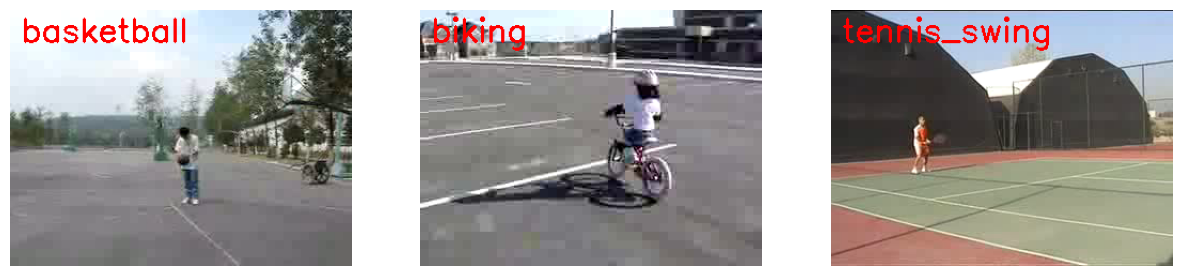

In [9]:
# Create a Matplotlib figure
plt.figure(figsize = (15, 10))

# Iterating through selected classes
for counter, selected_class_name in enumerate(classes_list, 1):

    # Getting class path
    class_path = os.path.join(
        dataset_directory,
        selected_class_name
    )

    # Getting group folders
    group_folders = os.listdir(class_path)

    # Randomly selecting a group
    selected_group = random.choice(group_folders)

    group_path = os.path.join(
        class_path,
        selected_group
    )

    # Getting video files
    video_files_names_list = os.listdir(group_path)

    # Randomly selecting a video
    selected_video_file_name = random.choice(
        video_files_names_list
    )

    # Full video path
    video_file_path = os.path.join(
        group_path,
        selected_video_file_name
    )

    # Reading video
    video_reader = cv2.VideoCapture(video_file_path)

    # Reading first frame
    success, bgr_frame = video_reader.read()

    # Release resources
    video_reader.release()

    # Continue only if frame successfully read
    if success:

        # Convert BGR to RGB
        rgb_frame = cv2.cvtColor(
            bgr_frame,
            cv2.COLOR_BGR2RGB
        )

        # Add class name
        cv2.putText(
            rgb_frame,
            selected_class_name,
            (10, 30),
            cv2.FONT_HERSHEY_SIMPLEX,
            1,
            (255, 0, 0),
            2
        )

        # Plot frame
        plt.subplot(1, 3, counter)

        plt.imshow(rgb_frame)

        plt.axis('off')

plt.show()

In [10]:
def create_dataset():

    # Declaring Empty Lists
    temp_features = []
    features = []
    labels = []

    # Iterating through all classes
    for class_index, class_name in enumerate(classes_list):

        print(f'Extracting Data of Class: {class_name}')

        # Class directory
        class_path = os.path.join(
            dataset_directory,
            class_name
        )

        # Getting group folders
        group_folders = os.listdir(class_path)

        # Iterating through groups
        for group in group_folders:

            group_path = os.path.join(
                class_path,
                group
            )

            # Getting video files
            files_list = os.listdir(group_path)

            # Iterating through videos
            for file_name in files_list:

                # Complete video path
                video_file_path = os.path.join(
                    group_path,
                    file_name
                )

                # Extract frames
                frames = frames_extraction(
                    video_file_path
                )

                # Add frames
                temp_features.extend(frames)

        # Randomly selecting frames
        features.extend(
            random.sample(
                temp_features,
                min(
                    max_images_per_class,
                    len(temp_features)
                )
            )
        )

        # Adding labels
        labels.extend(
            [class_index] *
            min(
                max_images_per_class,
                len(temp_features)
            )
        )

        # Clear temp list
        temp_features.clear()

    # Convert to numpy arrays
    features = np.asarray(features)

    labels = np.array(labels)

    return features, labels

In [12]:
def frames_extraction(video_path):

    # Empty List declared to store video frames
    frames_list = []

    # Reading the Video File Using the VideoCapture
    video_reader = cv2.VideoCapture(video_path)

    # Iterating through Video Frames
    while True:

        # Reading a frame from the video file
        success, frame = video_reader.read()

        # If Video frame was not successfully read
        if not success:
            break

        # Resize Frame
        resized_frame = cv2.resize(
            frame,
            (image_height, image_width)
        )

        # Normalize Frame
        normalized_frame = resized_frame / 255

        # Append frame
        frames_list.append(normalized_frame)

    # Release resources
    video_reader.release()

    # Return frames
    return frames_list

In [13]:
features, labels = create_dataset()

Extracting Data of Class: basketball
Extracting Data of Class: biking
Extracting Data of Class: tennis_swing


In [14]:
one_hot_encoded_labels = to_categorical(labels)

In [15]:
features_train, features_test, labels_train, labels_test = train_test_split(
    features,
    one_hot_encoded_labels,
    test_size=0.2,
    shuffle=True,
    random_state=seed_constant
)

In [16]:
def create_model():

    model = Sequential()

    model.add(
        Conv2D(
            filters=64,
            kernel_size=(3, 3),
            activation='relu',
            input_shape=(image_height, image_width, 3)
        )
    )

    model.add(
        Conv2D(
            filters=64,
            kernel_size=(3, 3),
            activation='relu'
        )
    )

    model.add(BatchNormalization())

    model.add(MaxPooling2D(pool_size=(2, 2)))

    model.add(GlobalAveragePooling2D())

    model.add(Dense(256, activation='relu'))

    model.add(BatchNormalization())

    model.add(Dense(model_output_size, activation='softmax'))

    model.summary()

    return model


model = create_model()

print("Model Created Successfully!")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 62, 62, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 60, 60, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 60, 60, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        16,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           771 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 57,411 (224.26 KB)

 Trainable params: 56,771 (221.76 KB)

 Non-trainable params: 640 (2.50 KB)

Model Created Successfully!


In [18]:
early_stopping_callback = EarlyStopping(
    monitor='val_loss',
    patience=15,
    mode='min',
    restore_best_weights=True
)

model.compile(
    loss='categorical_crossentropy',
    optimizer='Adam',
    metrics=["accuracy"]
)

In [19]:
model_training_history = model.fit(
    x=features_train,
    y=labels_train,
    epochs=20,
    batch_size=4,
    shuffle=True,
    validation_split=0.2,
    callbacks=[early_stopping_callback]
)

Epoch 1/20
1440/1440 ━━━━━━━━━━━━━━━━━━━━ 12s 4ms/step - accuracy: 0.5394 - loss: 0.9603 - val_accuracy: 0.6111 - val_loss: 1.2797
Epoch 2/20
1440/1440 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.7069 - loss: 0.6925 - val_accuracy: 0.6896 - val_loss: 1.1292
Epoch 3/20
1440/1440 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.7830 - loss: 0.5353 - val_accuracy: 0.8410 - val_loss: 0.4353
Epoch 4/20
1440/1440 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8349 - loss: 0.4341 - val_accuracy: 0.8611 - val_loss: 0.3259
Epoch 5/20
1440/1440 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8627 - loss: 0.3671 - val_accuracy: 0.9465 - val_loss: 0.1349
Epoch 6/20
1440/1440 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8771 - loss: 0.3282 - val_accuracy: 0.9618 - val_loss: 0.1215
Epoch 7/20
1440/1440 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8939 - loss: 0.2852 - val_accuracy: 0.9465 - val_loss: 0.1408
Epoch 8/20
1440/1440 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9023 - loss: 0.2653 -

In [20]:
model_evaluation_history = model.evaluate(
    features_test,
    labels_test
)

model_evaluation_loss, model_evaluation_accuracy = model_evaluation_history

print("Test Accuracy:", model_evaluation_accuracy)

57/57 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - accuracy: 0.9906 - loss: 0.0342
Test Accuracy: 0.9905555844306946


In [21]:
student_name = "Sajedah_Alqudaihi"

save_path = f"/content/drive/MyDrive/{student_name}_ucf11_model.keras"

model.save(save_path)

print(f"Model saved as {save_path}")

Model saved as /content/drive/MyDrive/Sajedah_Alqudaihi_ucf11_model.keras


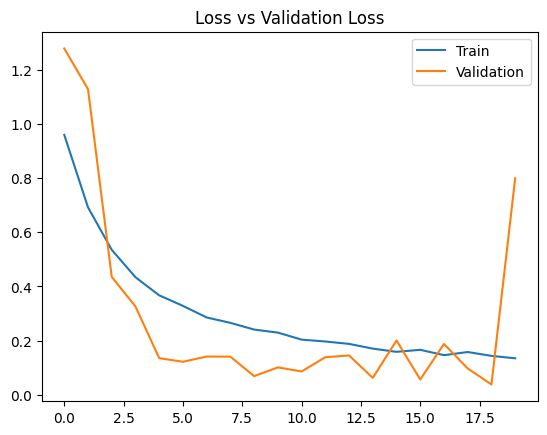

In [22]:
plt.plot(model_training_history.history['loss'])
plt.plot(model_training_history.history['val_loss'])

plt.title('Loss vs Validation Loss')

plt.legend(['Train', 'Validation'])

plt.show()

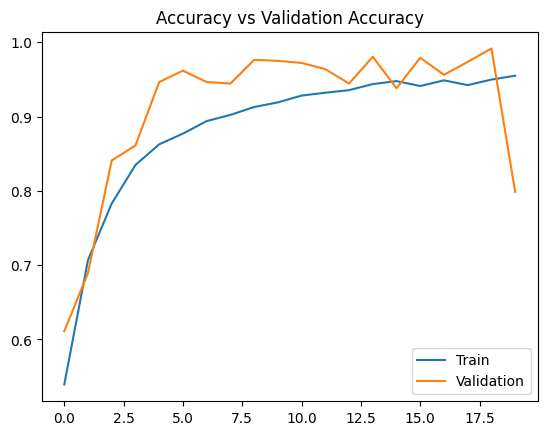

In [23]:
plt.plot(model_training_history.history['accuracy'])
plt.plot(model_training_history.history['val_accuracy'])

plt.title('Accuracy vs Validation Accuracy')

plt.legend(['Train', 'Validation'])

plt.show()

In [26]:
def predict_on_live_video(video_file_path, output_file_path, window_size):

    # Initialize deque for moving average
    predicted_labels_probabilities_deque = deque(
        maxlen=window_size
    )

    # Read video
    video_reader = cv2.VideoCapture(video_file_path)

    # Get video width and height
    original_video_width = int(
        video_reader.get(cv2.CAP_PROP_FRAME_WIDTH)
    )

    original_video_height = int(
        video_reader.get(cv2.CAP_PROP_FRAME_HEIGHT)
    )

    # Create video writer
    video_writer = cv2.VideoWriter(
        output_file_path,
        cv2.VideoWriter_fourcc(*'mp4v'),
        24,
        (original_video_width, original_video_height)
    )

    while True:

        # Read frame
        status, frame = video_reader.read()

        # Stop if no frame
        if not status:
            break

        # Resize frame
        resized_frame = cv2.resize(
            frame,
            (image_width, image_height)
        )

        # Normalize frame
        normalized_frame = resized_frame / 255

        # Predict probabilities
        predicted_labels_probabilities = model.predict(
            np.expand_dims(normalized_frame, axis=0),
            verbose=0
        )[0]

        # Append probabilities
        predicted_labels_probabilities_deque.append(
            predicted_labels_probabilities
        )

        # Apply moving average
        if len(predicted_labels_probabilities_deque) == window_size:

            predicted_labels_probabilities_np = np.array(
                predicted_labels_probabilities_deque
            )

            predicted_labels_probabilities_averaged = (
                predicted_labels_probabilities_np.mean(axis=0)
            )

            predicted_label = np.argmax(
                predicted_labels_probabilities_averaged
            )

            predicted_class_name = classes_list[
                predicted_label
            ]

            # Put text on frame
            cv2.putText(
                frame,
                predicted_class_name,
                (10, 30),
                cv2.FONT_HERSHEY_SIMPLEX,
                1,
                (0, 0, 255),
                2
            )

        # Write frame
        video_writer.write(frame)

    # Release resources
    video_reader.release()
    video_writer.release()

    print("Prediction completed!")

In [24]:
basketball_video = "/content/drive/MyDrive/videostotest (1).mp4"

biking_video = "/content/drive/MyDrive/videostotest (2).mp4"

tennis_video = "/content/drive/MyDrive/videostotest (3).mp4"

In [28]:
def make_average_predictions(video_file_path, predictions_frames_count):

    # Store probabilities
    predicted_labels_probabilities_np = np.zeros(
        (predictions_frames_count, model_output_size),
        dtype=float
    )

    # Read video
    video_reader = cv2.VideoCapture(video_file_path)

    # Total frames
    video_frames_count = int(
        video_reader.get(cv2.CAP_PROP_FRAME_COUNT)
    )

    # Skip window
    skip_frames_window = max(
        int(video_frames_count / predictions_frames_count),
        1
    )

    for frame_counter in range(predictions_frames_count):

        # Set frame position
        video_reader.set(
            cv2.CAP_PROP_POS_FRAMES,
            frame_counter * skip_frames_window
        )

        # Read frame
        success, frame = video_reader.read()

        if not success:
            continue

        # Resize frame
        resized_frame = cv2.resize(
            frame,
            (image_width, image_height)
        )

        # Normalize frame
        normalized_frame = resized_frame / 255

        # Predict
        predicted_labels_probabilities = model.predict(
            np.expand_dims(normalized_frame, axis=0),
            verbose=0
        )[0]

        predicted_labels_probabilities_np[
            frame_counter
        ] = predicted_labels_probabilities

    # Release video
    video_reader.release()

    # Average predictions
    average_predictions = predicted_labels_probabilities_np.mean(
        axis=0
    )

    predicted_label = np.argmax(average_predictions)

    predicted_class_name = classes_list[predicted_label]

    confidence = average_predictions[predicted_label]

    return predicted_class_name, confidence

In [29]:
predict_on_live_video(
    basketball_video,
    "/content/basketball_output.mp4",
    window_size=25
)

Prediction completed!


In [ ]:
predict_on_live_video(
    biking_video,
    "/content/biking_output.mp4",
    window_size=25
)

Prediction completed!


In [31]:
predict_on_live_video(
    tennis_video,
    "/content/tennis_output.mp4",
    window_size=25
)

Prediction completed!


In [34]:
predicted_class_name, confidence = make_average_predictions(
    basketball_video,
    predictions_frames_count=50
)

print("Predicted Class:", predicted_class_name)
print("Confidence:", confidence)

Predicted Class: basketball
Confidence: 0.5463666674867272


In [35]:
predicted_class_name, confidence = make_average_predictions(
    biking_video,
    predictions_frames_count=50
)

print("Predicted Class:", predicted_class_name)
print("Confidence:", confidence)

Predicted Class: biking
Confidence: 0.9274781364202499


In [36]:
predicted_class_name, confidence = make_average_predictions(
    tennis_video,
    predictions_frames_count=50
)

print("Predicted Class:", predicted_class_name)
print("Confidence:", confidence)

Predicted Class: biking
Confidence: 0.923495352268219
